In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from absl import app, flags, logging
from ml_collections import config_flags, ConfigDict
from tqdm.notebook import trange

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as patches
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from scipy.optimize import curve_fit

import json
import os

import icl.linear.train_single_index as tsi
from icl.linear.linear_utils import *
from icl.utils import visualize_attention

logging.set_verbosity(logging.INFO)
torch.set_printoptions(precision=3, sci_mode=False)
np.set_printoptions(precision=3, suppress=True)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
config = tsi.get_config()
model, log = tsi.train(config, verbose=True)

train_29bab6fffc4e2c15582c7e653bab656e already completed
Loaded model from ../results/single_index_regression/train_29bab6fffc4e2c15582c7e653bab656e/checkpoint.pt


In [7]:
work_dir = os.path.join("results", "single_index_regression")
exp_dir = os.path.join(work_dir, "train_29bab6fffc4e2c15582c7e653bab656e")
config_path = os.path.join(exp_dir, "config.json")
with open(config_path, "r") as f:
    config_dict = json.load(f)

config = ConfigDict(config_dict)
checkpoint_path = os.path.join(exp_dir, "checkpoint.pt")
checkpoint = torch.load(checkpoint_path, map_location=config.device)
data_type = torch.float
model = get_model(**config["model"], dtype=data_type)
model.load_state_dict(checkpoint["model"])
model = model.to(config.device)
train_task = tsi.get_task(**config["task"])
train_task.batch_size = 1
demo_data, demo_target = train_task.sample_from_task(train_task.task_pool[0], step=1)
attns = get_attn(model, demo_data, demo_target)
cap = 100
attns_capped = {layer_key: tensor[:, :cap, :cap] for layer_key, tensor in attns.items()}

widget = visualize_attention(attns_capped, mode='widget')
widget

In [8]:
train_task = tsi.get_task(**config["task"])
train_task.batch_size = 1024
l0 = 1
task_vectors = compute_task_vectors(config, model, train_task, l0)

In [12]:
plot_task_vector_variance_with_fit(task_vectors)

In [13]:
plot_task_vector_differences(task_vectors)

In [14]:
plot_pairwise_task_vector_variance(task_vectors)

In [76]:
tvs_means = task_vectors.mean(dim=-2)
tvs_mean_weighted = tvs_means[:, -10:].mean(dim=1)# weighted_average_favor_late_batched(tvs_means, mode="exp")

t0 = 5
train_task.batch_size = 256
print(f"Memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
criterion = nn.MSELoss(reduction='none')

for k in range(config.task.n_tasks):
    torch.cuda.empty_cache()
    task_idx = k
    query_data, query_target = train_task.sample_from_task(train_task.task_pool[task_idx], step=6)
    preds_rand = predict_with_task_vector(
            model=model,
            query_data=query_data[:, :(3*t0+3)],
            query_target=query_target[:, :(3*t0+3)],
            task_vector=tvs_mean_weighted[task_idx],
            l=l0,              # same layer
            pad="mapsto",      # same position
            pos=3*t0+1
        )
    with torch.no_grad():
        preds = model(query_data, query_target)
    errors_rand = criterion(preds_rand[:, t0], query_target[:, t0].to(preds_rand.device))  # shape: (batch,)
    errors_base = criterion(preds[:, t0], query_target[:, t0].to(preds_rand.device))
    loss = errors_rand.mean()
    baseline_loss = errors_base.mean()
    
    std_rand = errors_rand.std(unbiased=True)
    std_base = errors_base.std(unbiased=True)
    print(f"{t0}-shot loss w. injected task vector: {loss.item():.3f} ({std_rand.item():.3f})")
    print(f"{t0}-shot loss w.o. injected task vector: {baseline_loss.item():.3f} ({std_base.item():.3f})")

Memory allocated: 0.03 GB
5-shot loss w. injected task vector: 1.297 (2.212)
5-shot loss w.o. injected task vector: 0.631 (2.742)
5-shot loss w. injected task vector: 1.331 (1.960)
5-shot loss w.o. injected task vector: 0.581 (1.182)
5-shot loss w. injected task vector: 2.256 (3.338)
5-shot loss w.o. injected task vector: 0.590 (1.590)


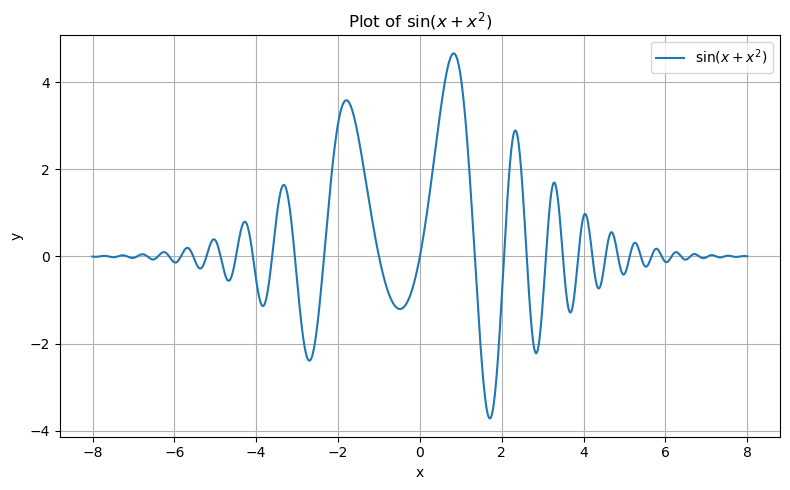

In [64]:
import torch
import matplotlib.pyplot as plt

# Generate x values
x = torch.linspace(-8, 8, steps=1000)
y = 5 * torch.sin(x + x**2) * torch.exp(-x**2 / 10)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), y.numpy(), label=r'$\sin(x + x^2)$')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Plot of $\sin(x + x^2)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
